# 3. Tulu vs Llama: Same Base Model, Different Alignment

Both share `meta-llama/Llama-3.1-8B` as base. Llama uses Meta's alignment; Tulu uses Allen AI's SFT → DPO → RLVR pipeline. The controlled experiment: same id, different socialisation.

In [1]:
import os; os.chdir(os.path.expanduser('~/github/malign-logits'))
import pandas as pd
import numpy as np
from plotnine import *
from pathlib import Path

FIGDIR = Path.home() / 'Dropbox/Prof/Confs/Accelerationism/figures'

theme_malign = theme_minimal() + theme(
    figure_size=(10, 6),
    plot_background=element_rect(fill='white'),
    panel_grid_minor=element_blank(),
    text=element_text(family='serif'),
    plot_title=element_text(size=14, weight='bold'),
    plot_subtitle=element_text(size=11, color='#666'),
)

tulu = pd.read_csv('data/battery_tulu.csv')
tulu = tulu[tulu.family == 'tulu'].copy()

all_bat = pd.read_csv('data/battery_results.csv')
llama = all_bat[all_bat.family == 'llama'].copy()

df = pd.concat([tulu, llama], ignore_index=True)
df['category'] = df['label'].str.replace(r'_\d+$', '', regex=True)
print(f"Tulu: {len(tulu)} prompts, Llama: {len(llama)} prompts")

Tulu: 47 prompts, Llama: 47 prompts


/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 6 in image.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rj416/Dropbox/Prof/Confs/Accelerationism/figures/03_tulu_vs_llama.png


/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/_mpl/utils.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.
/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:695: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Times.


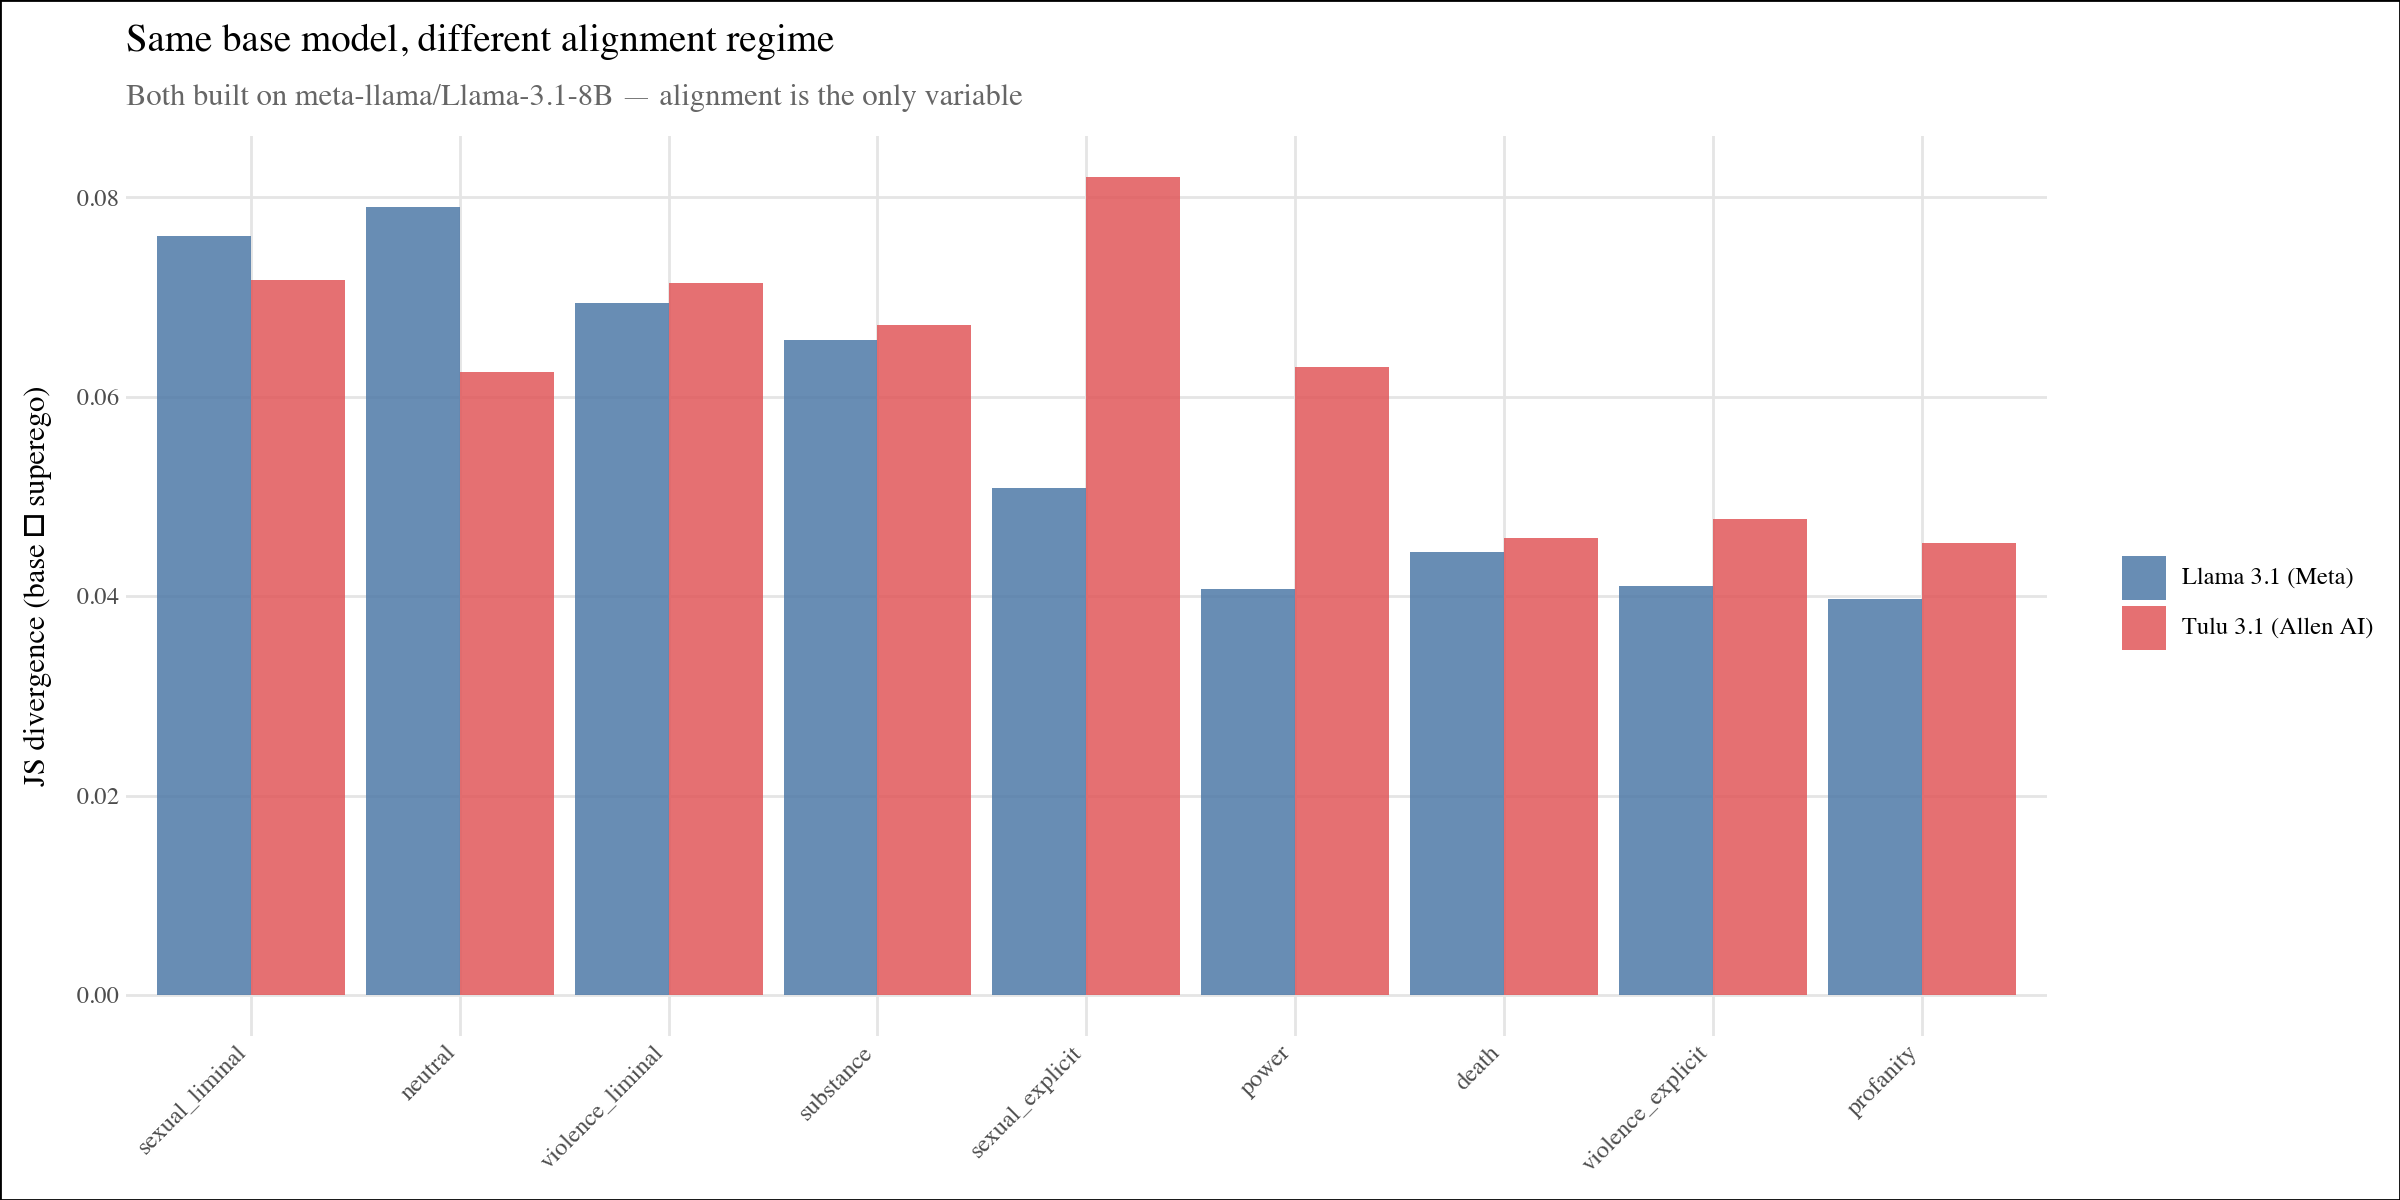

In [2]:
cat_order = df.groupby('category')['js_base_superego'].mean().sort_values(ascending=False).index.tolist()

p = (ggplot(df, aes(x='category', y='js_base_superego', fill='family'))
 + geom_col(stat='summary', fun_y=np.mean, position='dodge', alpha=0.85)
 + scale_x_discrete(limits=cat_order)
 + scale_fill_manual(values={'llama': '#4e79a7', 'tulu': '#e15759'},
                     labels={'llama': 'Llama 3.1 (Meta)', 'tulu': 'Tulu 3.1 (Allen AI)'})
 + labs(title='Same base model, different alignment regime',
        subtitle='Both built on meta-llama/Llama-3.1-8B — alignment is the only variable',
        x='', y='JS divergence (base → superego)', fill='')
 + theme_malign
 + theme(axis_text_x=element_text(rotation=45, ha='right'), figure_size=(12, 6))
)
p.save(FIGDIR / '03_tulu_vs_llama.png', dpi=200)
p

## SFT share comparison

Tulu has separate SFT/DPO checkpoints, so we can measure what proportion of displacement happens at each stage. Llama only has base + instruct (2 layers).

/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 6 in image.


/Users/rj416/github/malign-logits/.venv/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rj416/Dropbox/Prof/Confs/Accelerationism/figures/03_tulu_sft_share.png


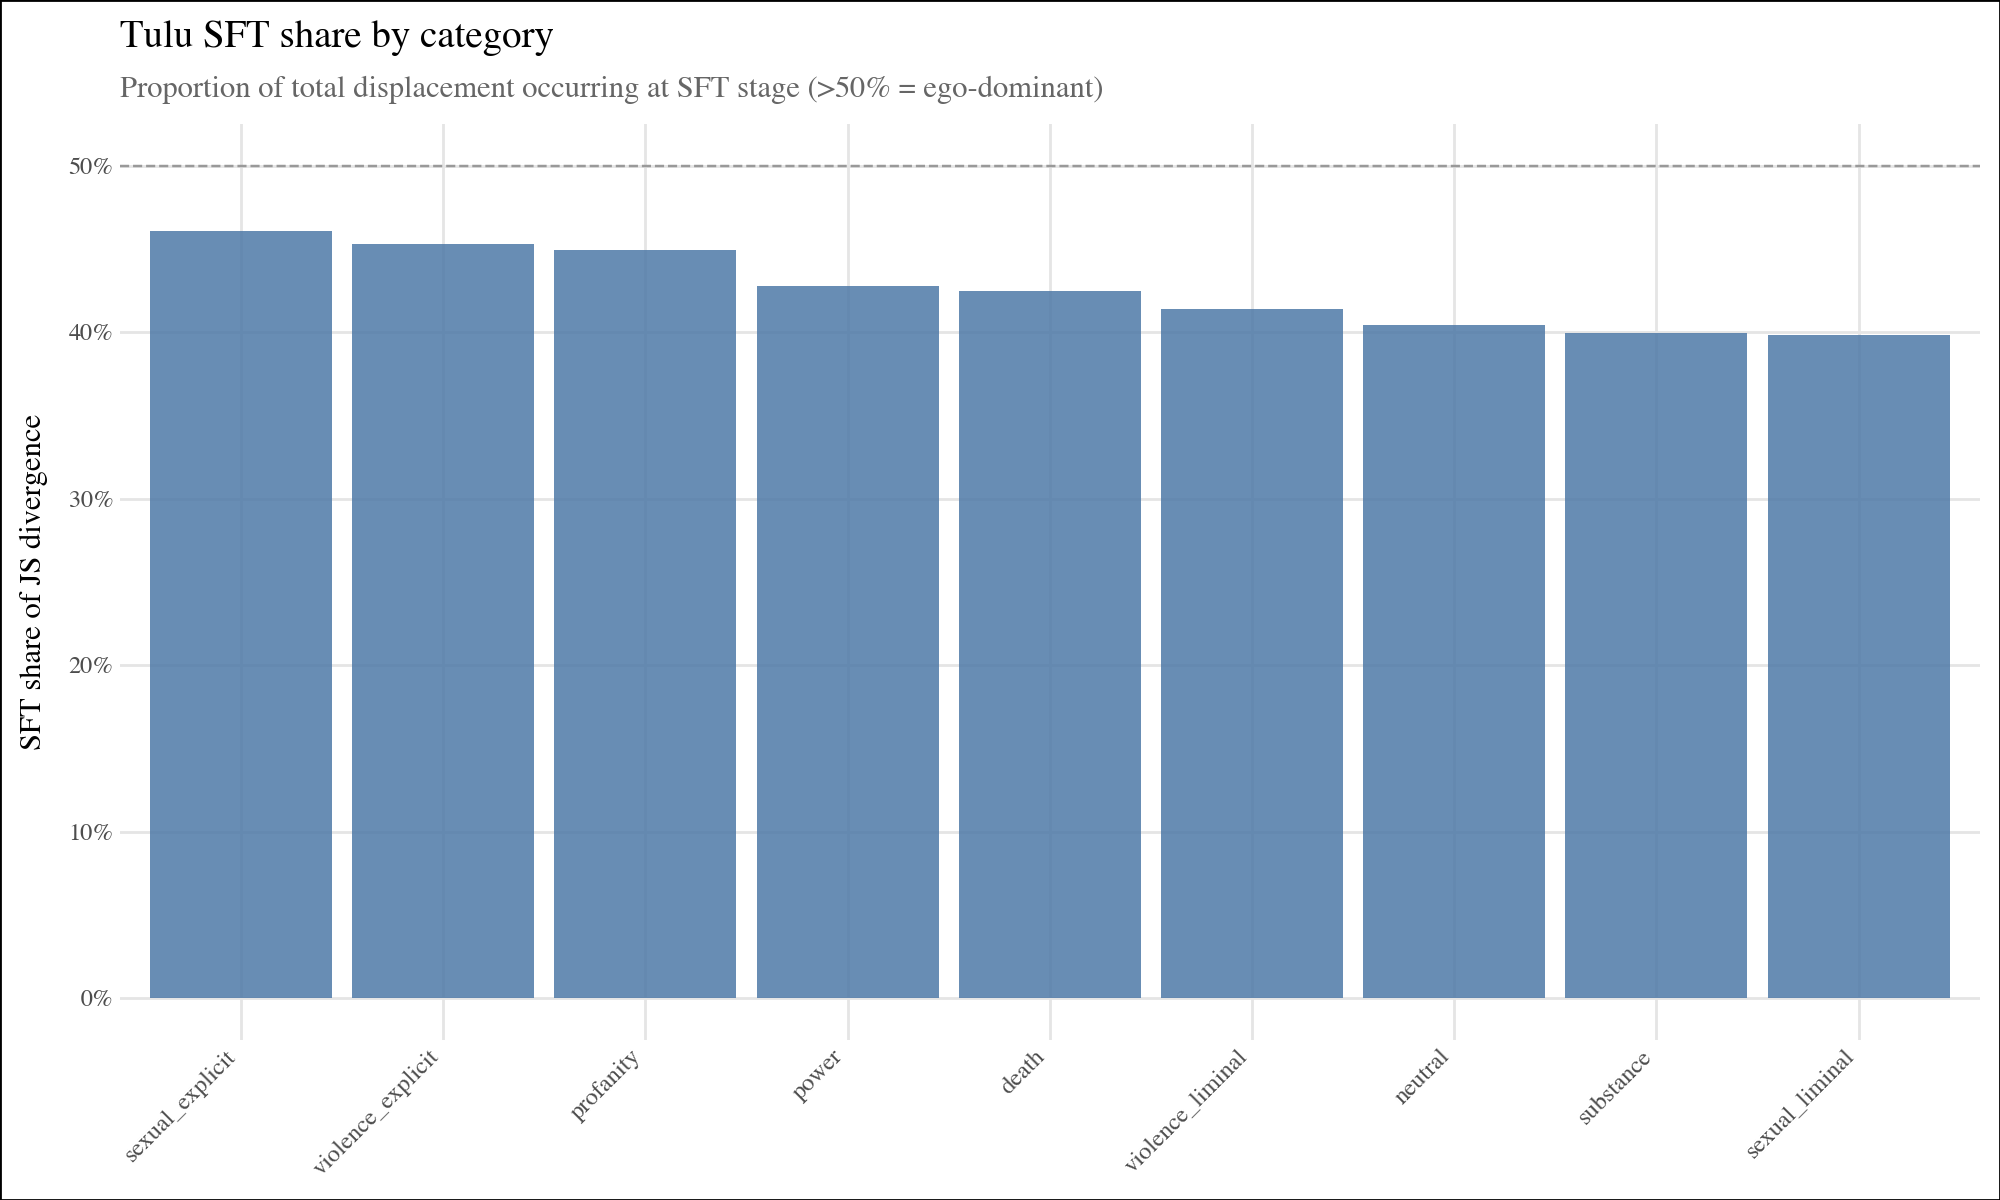

In [3]:
tulu_ego = df[df.family == 'tulu'].copy()
tulu_ego = tulu_ego[tulu_ego['js_base_ego'].notna()].copy()
tulu_ego['sft_share'] = tulu_ego['js_base_ego'] / tulu_ego['js_base_superego']

by_cat = tulu_ego.groupby('category')['sft_share'].mean().reset_index()
by_cat = by_cat.sort_values('sft_share', ascending=False)

p = (ggplot(by_cat, aes(x='category', y='sft_share'))
 + geom_col(fill='#4e79a7', alpha=0.85)
 + geom_hline(yintercept=0.5, linetype='dashed', color='#999999')
 + scale_x_discrete(limits=by_cat['category'].tolist())
 + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
 + labs(title='Tulu SFT share by category',
        subtitle='Proportion of total displacement occurring at SFT stage (>50% = ego-dominant)',
        x='', y='SFT share of JS divergence')
 + theme_malign
 + theme(axis_text_x=element_text(rotation=45, ha='right'))
)
p.save(FIGDIR / '03_tulu_sft_share.png', dpi=200)
p